# DEF-D Fysieke Ontwerpopdracht 5 Invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 12     |  |
| :-------------|:-------------|
| Jesse Langenberg | 6290116 |
| Roel van der Ouderaa| 6424139 |
| Hugo Rutten | 6541593 |

## Opdracht 1: Planning.

| Planning Groep: 12     |Tijdstip / Tijdspanne  | door wie  |
|---|---|---|
| Arduino testen| 12:00 | Jesse |
| ontwerp-eis berekenen| 12:00 | Hugo en Roel |
| Accelerator begrijpen | 12:45 | ---|
| ontwerpen en testen | 13:45-16:30 | hele groep |
| Eerste ontwerp af | 16:00 | ---|
| itereren, testen en opruimen | 16:30-17:30 | hele groep |
| Pauze 1| 12:45-13:45 | hele groep |


Run onderstaande cel om alle benodigde libraries te laden. Mogelijk voeg je er zelf nog een aantal toe later vandaag. 

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
import math

## Opdracht 2a: Opsplitsen taak 1: Arduino
Vul onderstaande tabel in:

| onderwerp    | antwoord  |
|---|---|
| hoe moeilijk (schaal 1 - 10) |  |
| hoe lang voor één meting |  |
| verwacht nauwkeurigheid meting |  |

## Opdracht 2b: Opsplitsen taak 2: afleiding ontwerpeis

In [2]:
# Bereken hier je benodigde kantelfrequentie
#A_m/A_v = 1/(1-w^2/w_0^2) dit moet gelijk zijn aan 1/3 om een verdemping van een factor 3 te krijgen.
# dus abs(1-w^2/w_0^2) moet gelijk zijn aan 3
# uit 1-w^2/w_0^2 = -2 volgt een negatieve frequentie dus 1-w^2/w_0^2 = 4 
# dus geldt w_0 = sqrt((w)^2/4)

w = 10*np.pi
w_0 = np.sqrt((w**2)/4)
print('De benodigde eigenfrequentie = ',w_0,'rad/s')

De benodigde eigenfrequentie =  15.707963267948966 rad/s


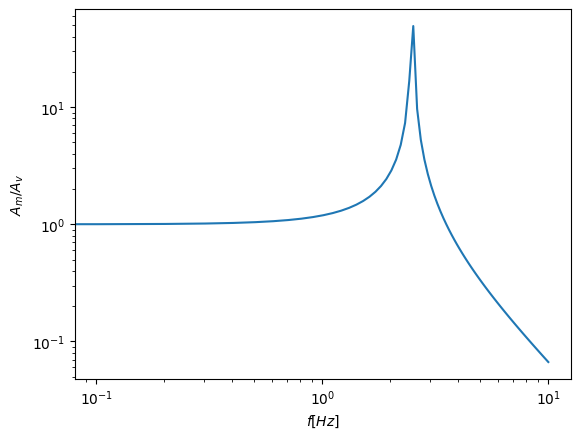

In [3]:
# Voeg hier je plot in.

def formule(f):
    omega_0 = np.sqrt(((10*np.pi)**2)/4)
    return np.abs(1 / (1-((2*np.pi * f)**2)/(omega_0 **2)))
f_rand = np.linspace(0, 10, 100)
plt.loglog(f_rand, formule(f_rand))
plt.ylabel('$A_m / A_v$')
plt.xlabel("$f [Hz]$")
plt.show()

In [4]:
# Bereken hier de minimale Delta-x waarbij je aan de eis van de opdracht voldoet.
# w_0 = sqrt(g/dx), hieruit volgt:
g = 9.81 #m/s^2
dx = g/(w_0**2)

print('De minimale dx =',dx,'m')


De minimale dx = 0.039758432461253344 m


## Opdracht 3: Plot de grafiek.

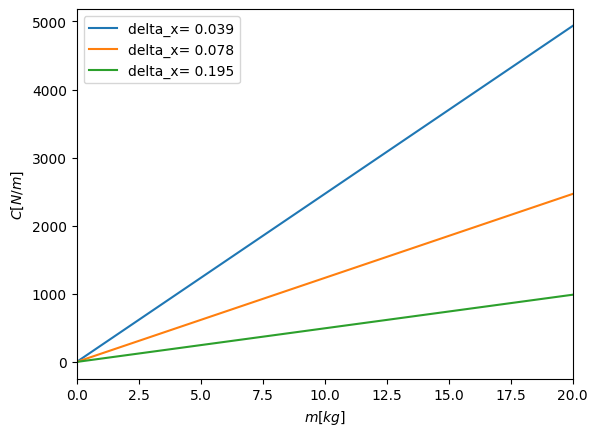

In [5]:
# Voeg hier je plot in. Lees goed de opdracht wat er in de grafiek moet staan!
# Het is ook handig om je grafiek op te slaan, doe dat door met plt.savefig().

omega_0 = np.sqrt(((10*np.pi)**2)/4)
massa = np.linspace(0, 20, 100)
def variatie_C_m(m):
    return (omega_0**2 * m) 

plt.xlim(np.min(massa), np.max(massa))
plt.plot(massa, variatie_C_m(massa), label='delta_x= 0.039')
plt.plot(massa, variatie_C_m(massa)*0.5, label='delta_x= 0.078')
plt.plot(massa, variatie_C_m(massa)*0.2, label='delta_x= 0.195')
plt.xlabel('$m [kg]$')
plt.ylabel('$C [N/m]$')
plt.legend()
plt.show()

## Opdracht 4: Verander $\Delta x$.

We kunnen $\Delta x$ verhogen door:

- De veerconstante te verlagen.
- De massa te verhogen.

Vul onderstaande aan. Geef eventueel met tekst aan waarom je hiervoor gekozen hebt, als extra informatie richting de nakijkers. 

Als groep gaan we mikken op een $\Delta x$ van: 5 cm

## Opdracht 5: Schets.

##### schets opstelling: 
<img src="ontwerpschets5.jpeg" width="400">

## Opdracht 6: Beslissing evaluatie

Voldoet je ontwerp aan de eisen? Beantwoord de volgende vragen:

### Wat is de $\Delta x$ van je ontwerp?

**11 cm**

### Wordt die $\Delta x$ behaald met je gekozen massa en veer?

**ja**

### hoeveel verder kan je massa-veer systeem nog uitrekken / indrukken?
Wat is de limiet aan je veer / verend materiaal voordat het niet meer lineair reageert volgens de wet van Hooke?

**Het elastiek kan nog 70 cm worden uitgerekt. Wanneer het elastiek niet onder spanning staat volgt deze niet de wet van Hooke.**

### Is dat genoeg om straks metingen te kunnen doen?
Hou er rekening mee dat je trillingen een amplitude in de orde grote van een paar centimeter gaan hebben, minder is met deze opzet moeilijk te realiseren.

**ja**

### Gaat je ontwerp dus voldoen aan de eis?

**ja**

Als je hier positief geantwoord heb, maak dan nog een keer een plot van amplitude overdracht (y-as) versus frequentie (x-as) zoals je hierboven ook al een keer gedaan heb, maar plot nu twee verschillende overdrachten in de grafiek: één die je al had: behorende bij de grens van de ontwerp-eis en één behorende bij je eigen ontwerp. Lees af dat je voor je ontwerp daadwerkelijk onder de eis grafiek zit op de kritieke frequentie!

Deze grafiek heb je later weer nodig om je gemeten punten aan toe te voegen. Ga daarna je massa-veer systeem daadwerkelijk bouwen.

Als je hier negatief geantwoord hebt, kopieer onder deze cel dan alle cellen van Synthese tot en met Evaluation & decision en doorloop dat deel van het ontwerp proces nogmaals.

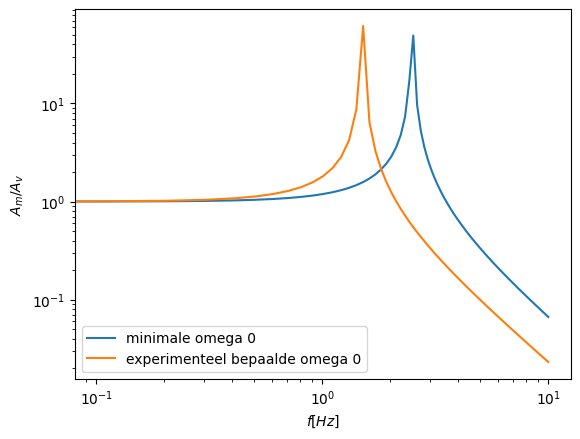

In [6]:
# Voeg hier je plot in.

def formule(f, omega_0):
    return np.abs(1 / (1-((2*np.pi * f)**2)/(omega_0 **2)))
omega_02 = np.sqrt(9.81/0.11)
omega_01 = np.sqrt(((10*np.pi)**2)/4)

f_rand = np.linspace(0, 10, 100)
plt.loglog(f_rand, formule(f_rand, omega_01),label='minimale omega 0')
plt.loglog(f_rand, formule(f_rand, omega_02),label='experimenteel bepaalde omega 0')
plt.legend()
plt.ylabel('$A_m / A_v$')
plt.xlabel("$f [Hz]$")
plt.show()



## Opdracht 7: Plotten maar

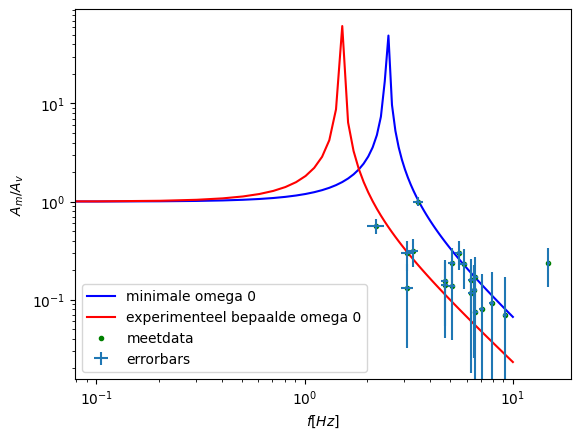

In [7]:
# Voeg hier je plots in.
# Voeg hier je plot in.

def formule(f, omega_0):
    return np.abs(1 / (1-((2*np.pi * f)**2)/(omega_0 **2)))
omega_02 = np.sqrt(9.81/0.11)
omega_01 = np.sqrt(((10*np.pi)**2)/4)

f_rand = np.linspace(0, 10, 100)

freq = np.array([3.1,6.3,5.8,3.3,3.1,6.6,5.1,7.1,4.7,6.3,6.5,6.6,4.7,5.1,2.2,3.5,14.8,9.2,7.9,5.5])
ampm = np.array([0.14,0.12,1.17,0.63,0.12,0.22,0.37,0.35,0.43,0.67,0.25,0.28,0.5,0.29,0.17,0.18,1.39,0.46,0.23,0.83])
ampv = np.array([0.47,0.76,5.12,1.99,0.91,1.3,2.66,4.34,2.79,5.68,1.99,3.72,3.55,1.24,0.3,0.18,5.89,6.67,2.51,2.78]) 

plt.loglog(f_rand, formule(f_rand, omega_01),'b',label='minimale omega 0')
plt.loglog(f_rand, formule(f_rand, omega_02),'r',label='experimenteel bepaalde omega 0')
plt.loglog(freq,ampm/ampv,'g.', label='meetdata')
plt.errorbar(freq,ampm/ampv, xerr= 0.2, yerr=0.1,fmt='none',label='errorbars' )
plt.legend()
plt.ylabel('$A_m / A_v$')
plt.xlabel("$f [Hz]$")
plt.show()



De punten komen niet altijd even goed overeen met de verwachting. Dit komt waarschijnlijk door een te grote onzekerheid en ruis tijdens de metingen.

## Opdracht 8: Leerdoelen
Voeg hieronder zelf kopjes toe om aan te geven wat bij welk leerdoel hoort. 

Leerdoel: Inzien dat de parameters in een differentiaalvergelijking ontwerpparameters zijn die een ontwerpruimte opspannen.

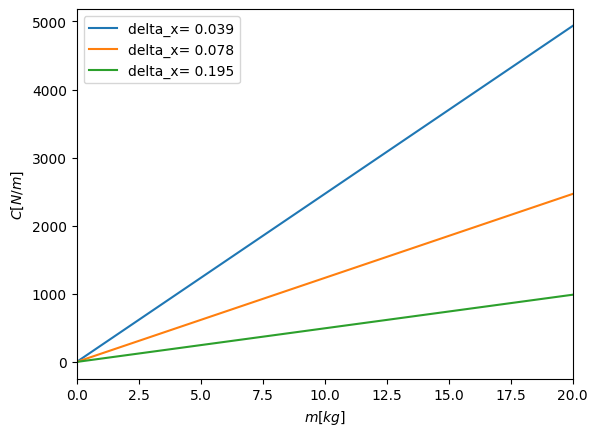

In [8]:
# Voeg hier je plot in. Lees goed de opdracht wat er in de grafiek moet staan!
# Het is ook handig om je grafiek op te slaan, doe dat door met plt.savefig().

omega_0 = np.sqrt(((10*np.pi)**2)/4)
massa = np.linspace(0, 20, 100)
def variatie_C_m(m):
    return (omega_0**2 * m) 

plt.xlim(np.min(massa), np.max(massa))
plt.plot(massa, variatie_C_m(massa), label='delta_x= 0.039')
plt.plot(massa, variatie_C_m(massa)*0.5, label='delta_x= 0.078')
plt.plot(massa, variatie_C_m(massa)*0.2, label='delta_x= 0.195')
plt.xlabel('$m [kg]$')
plt.ylabel('$C [N/m]$')
plt.legend()
plt.show()





Leerdoel: Op basis van een differentiaal vergelijking een keuze maken voor parameters en die vervolgens kunnen vertalen in een fysiek ontwerp.

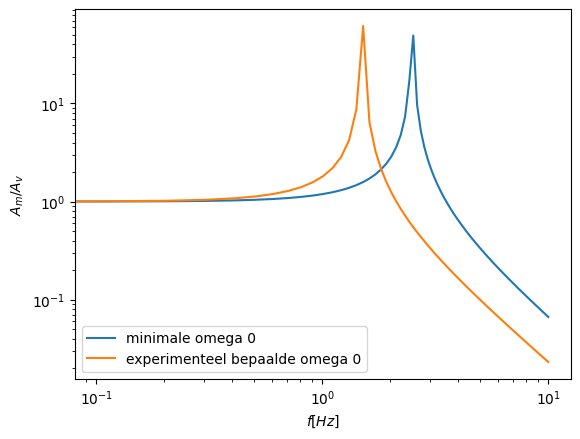

In [9]:
# Voeg hier je plot in.

def formule(f, omega_0):
    return np.abs(1 / (1-((2*np.pi * f)**2)/(omega_0 **2)))
omega_02 = np.sqrt(9.81/0.11)
omega_01 = np.sqrt(((10*np.pi)**2)/4)

f_rand = np.linspace(0, 10, 100)
plt.loglog(f_rand, formule(f_rand, omega_01),label='minimale omega 0')
plt.loglog(f_rand, formule(f_rand, omega_02),label='experimenteel bepaalde omega 0')
plt.legend()
plt.ylabel('$A_m / A_v$')
plt.xlabel("$f [Hz]$")
plt.show()